In [1]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [8]:
#Column names from documnetation 
columns = [
    'symboling','normalized_losses','make','fuel_type','aspiration','num_doors',
    'body_style','drive_wheels','engine_location','wheel_base','length','width',
    'height','curb_weight','engine_type','num_cylinders','engine_size','fuel_system',
    'bore','stroke','compression_ratio','horsepower','peak_rpm','city_mpg','highway_mpg','price'
]

In [10]:
df = pd.read_csv("/Users/mayankdixit/Documents/Learning/EDA/automobile/imports-85.data", names=columns, na_values='?')
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [12]:
df.shape

(205, 26)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_doors          203 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_cylinders      205 non-null    str    
 16  engine_size        205 non-null    in

In [ ]:
#Null values
df.isnull().sum().sort_values(ascending=False)

normalized_losses    41
price                 4
stroke                4
bore                  4
peak_rpm              2
num_doors             2
horsepower            2
engine_type           0
highway_mpg           0
city_mpg              0
compression_ratio     0
fuel_system           0
engine_size           0
num_cylinders         0
symboling             0
height                0
width                 0
length                0
wheel_base            0
engine_location       0
drive_wheels          0
body_style            0
aspiration            0
fuel_type             0
make                  0
curb_weight           0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Target variable analysis
df['price'].describe()

count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64

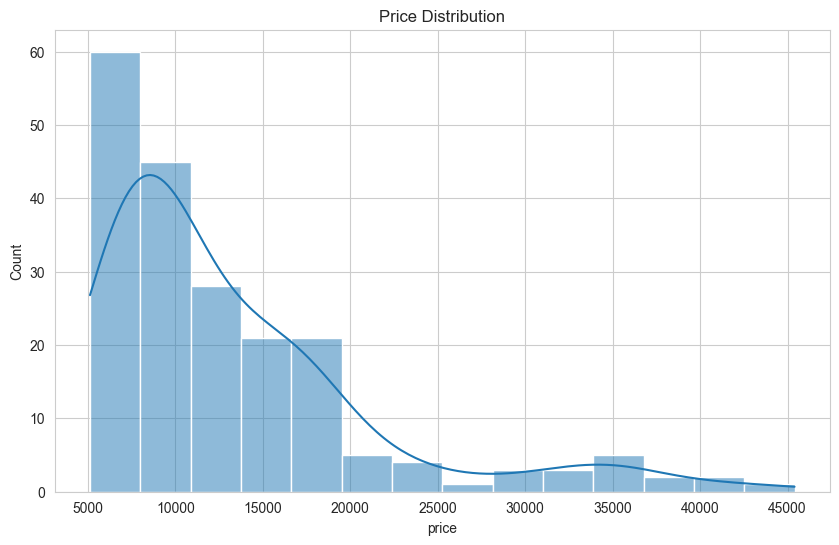

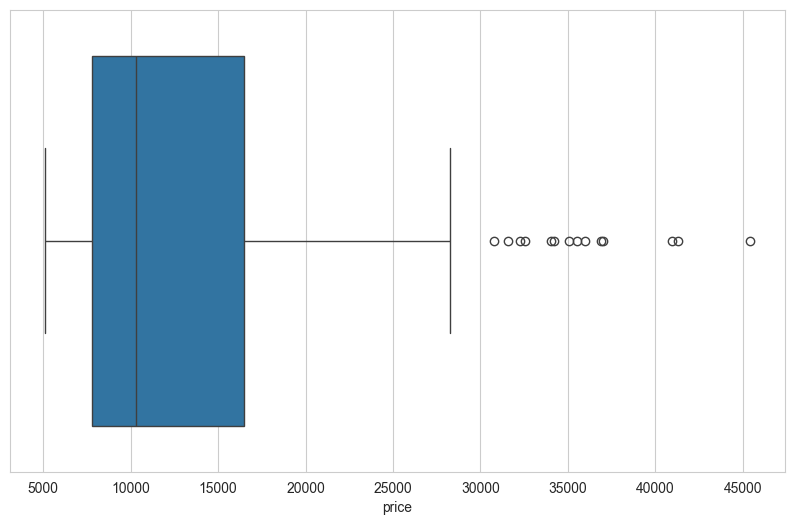

In [ ]:
# Price Distribution
sns.histplot(df['price'], kde= True)
plt.title("Price Distribution")
plt.show()

sns.boxplot(x =df['price'])
plt.show()

__Observations:__
- Data is strongly right skewed.
- Luxury outliers
- Large variance

In [19]:
# Data type correction 
# Numerical Features 

num_cols = [
    'normalized_losses','bore','stroke','horsepower',
    'peak_rpm','price'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_doors          203 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_cylinders      205 non-null    str    
 16  engine_size        205 non-null    in

In [22]:
num_features = df.select_dtypes(include=np.number).columns
df[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
normalized_losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00
wheel_base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curb_weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
engine_size,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94
stroke,201.0,3.255423,0.316717,2.07,3.11,3.29,3.41,4.17


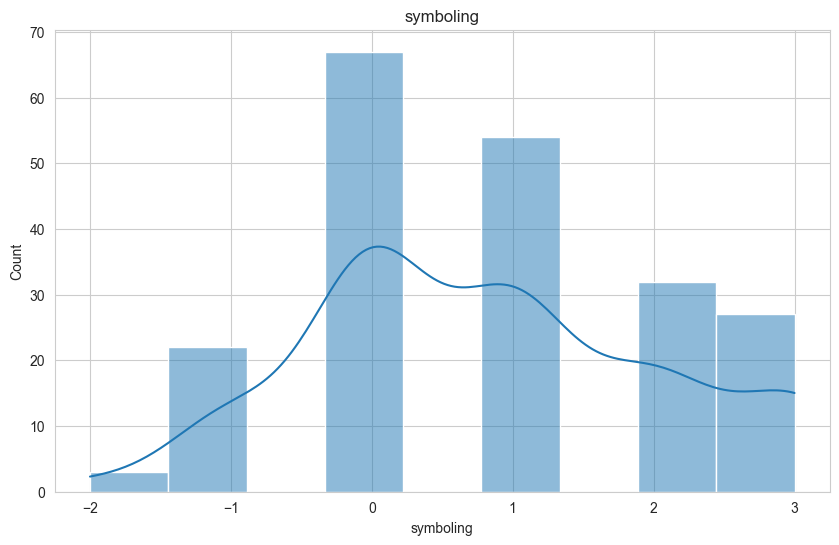

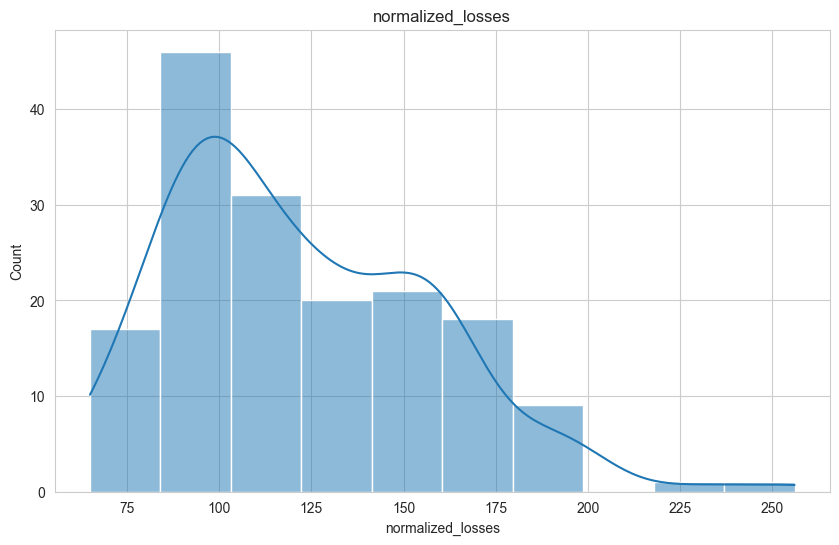

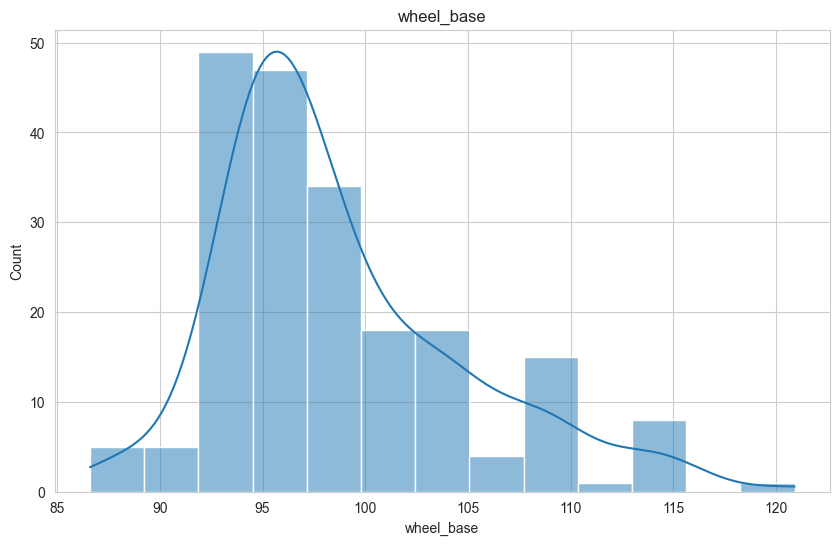

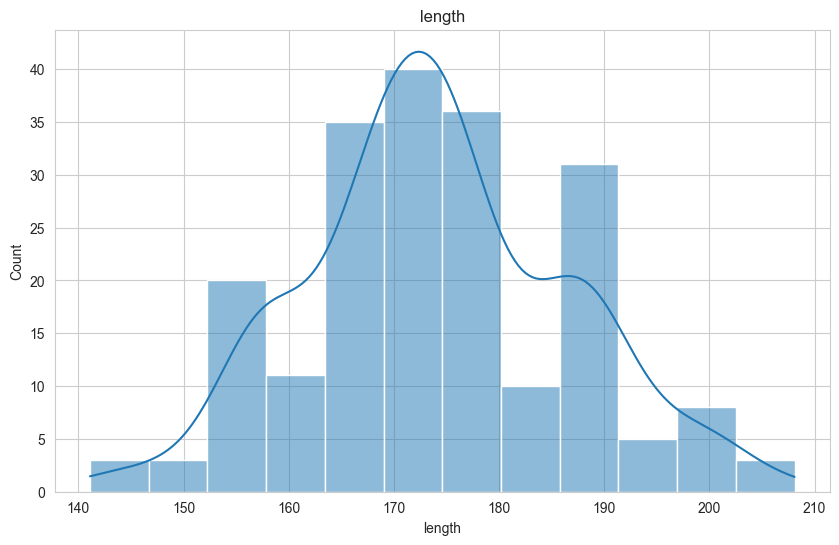

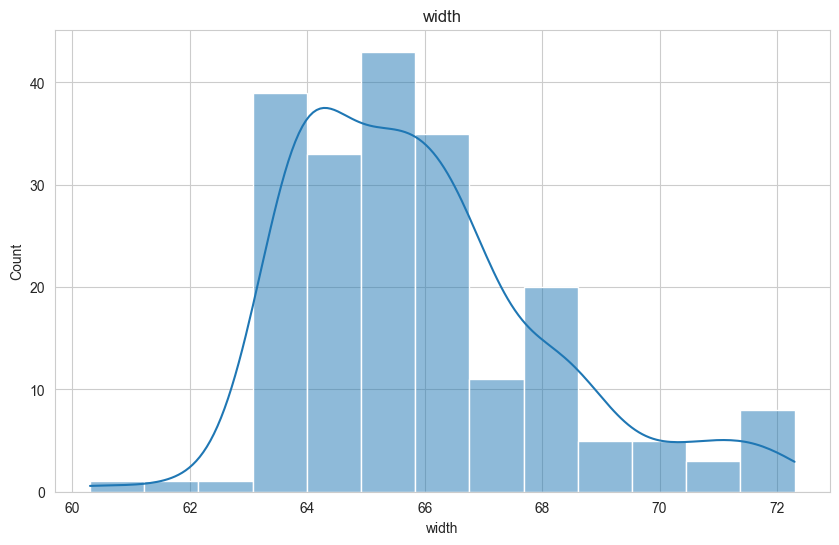

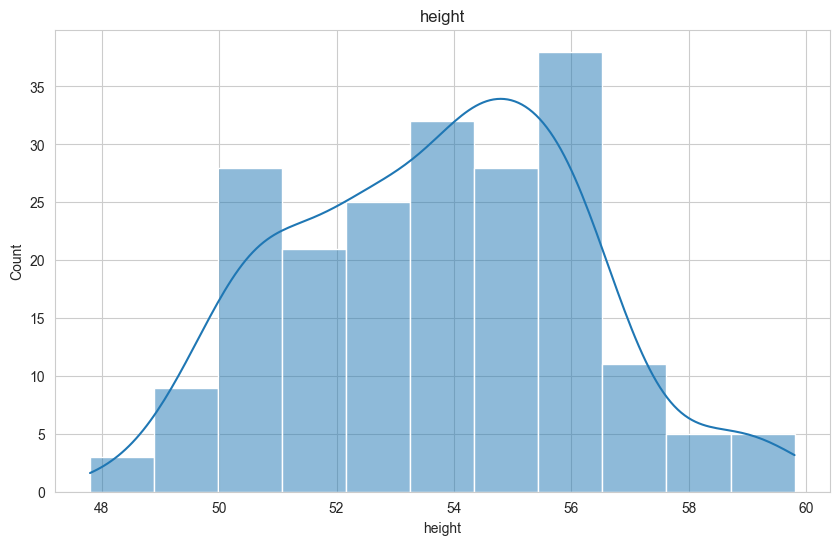

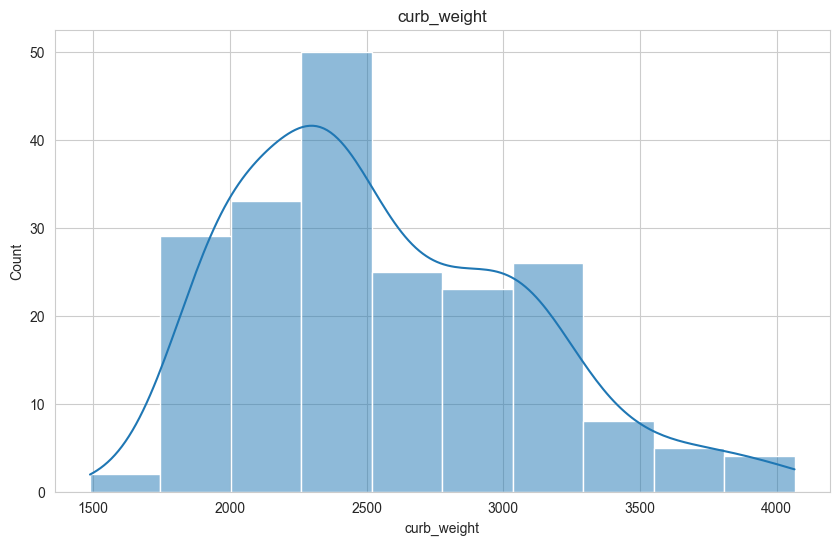

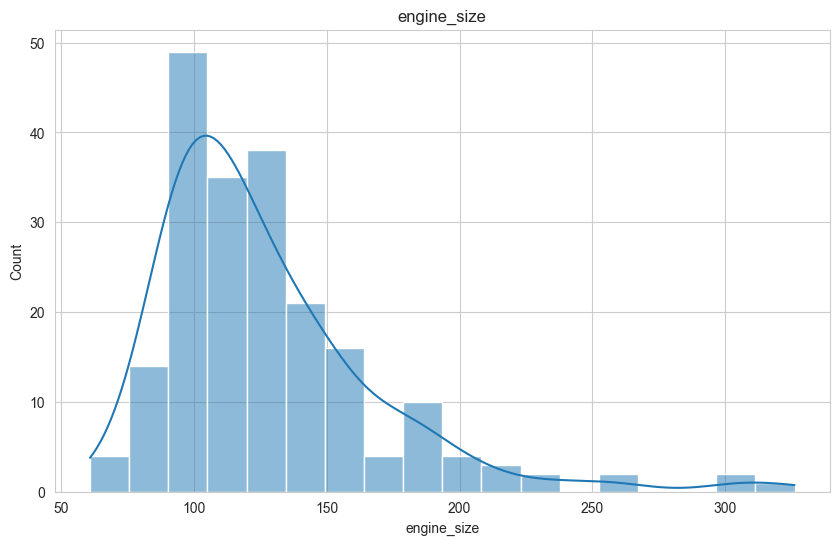

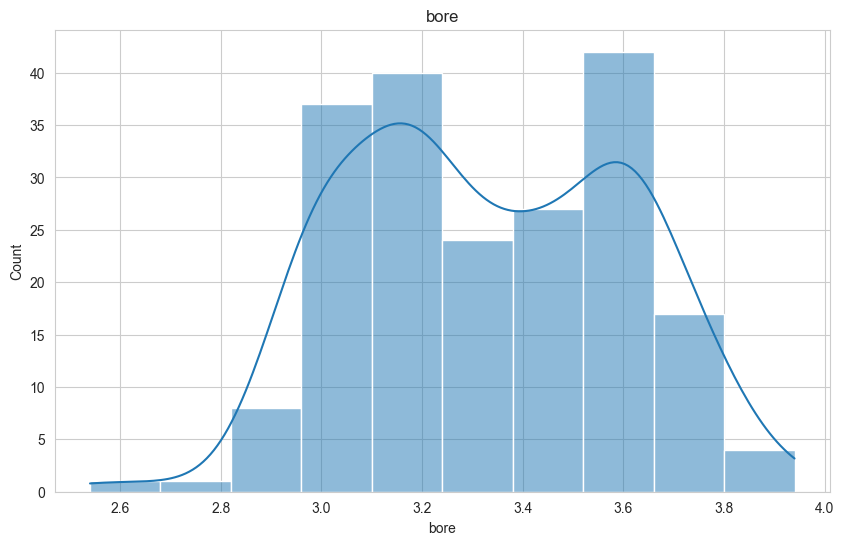

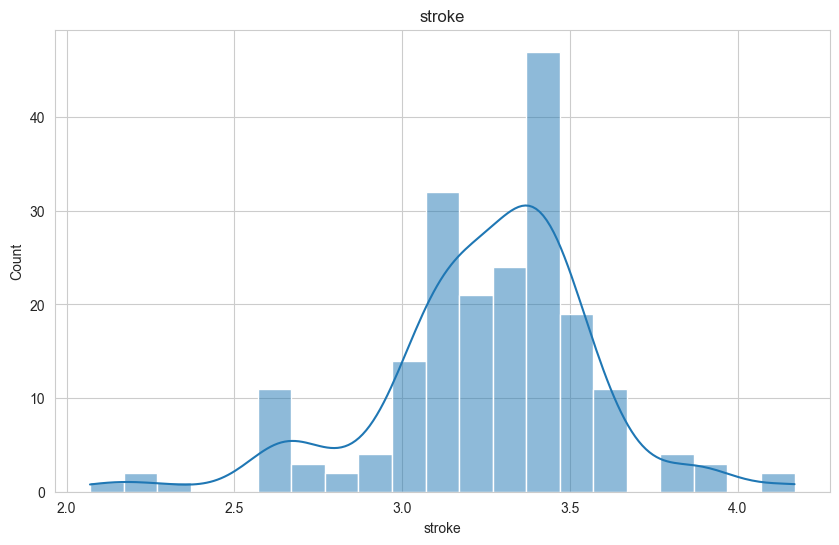

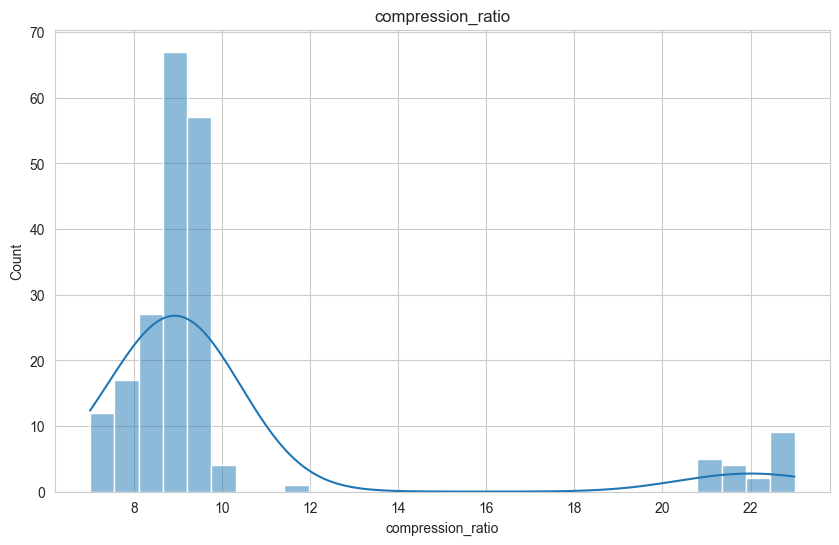

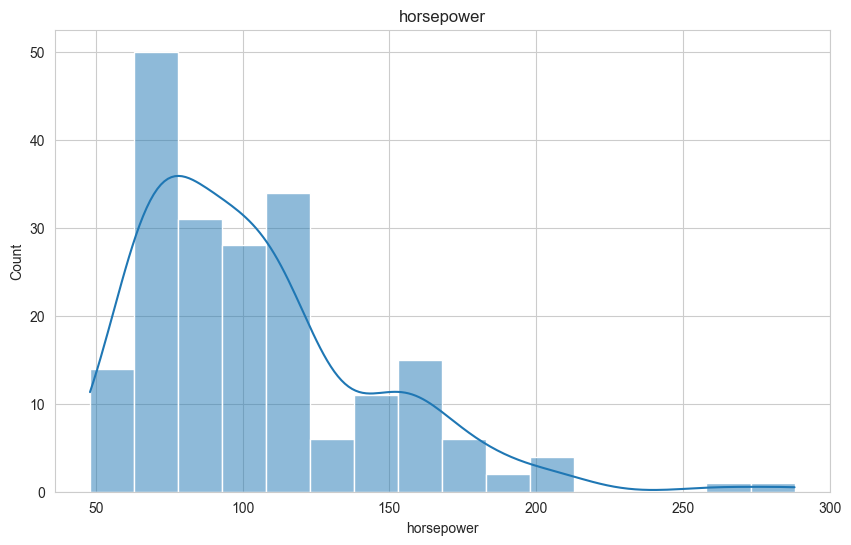

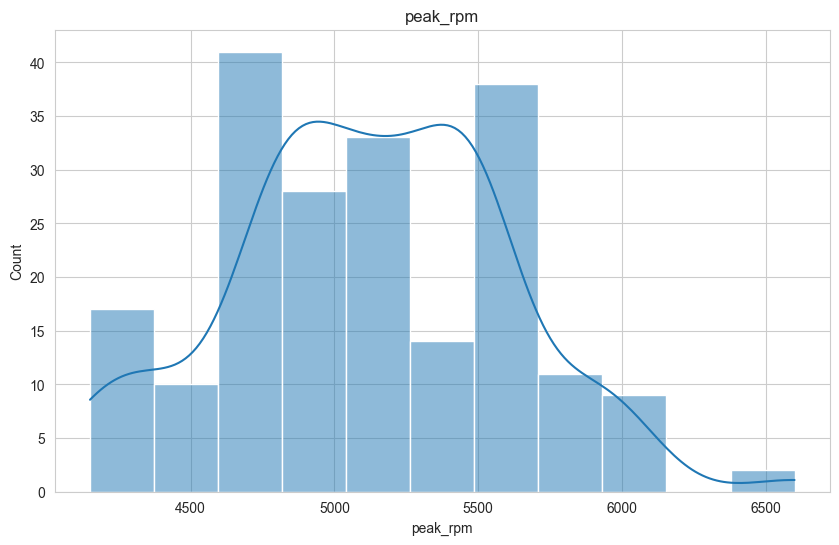

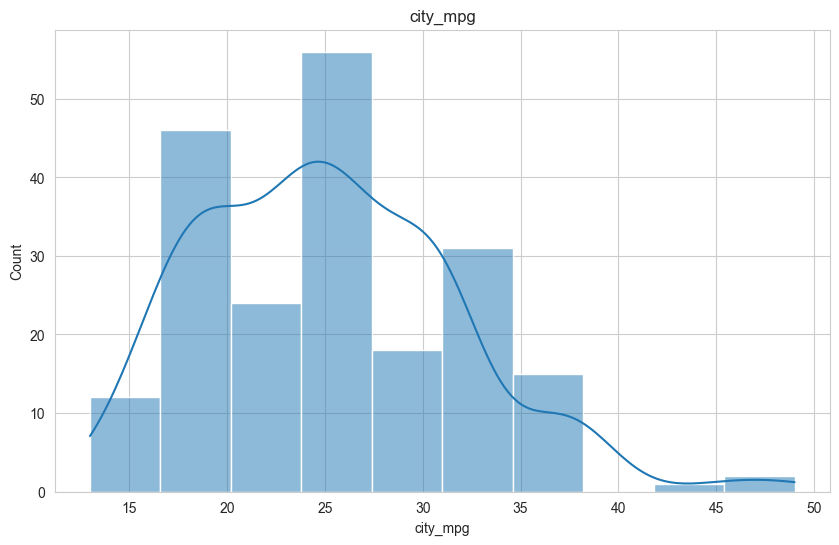

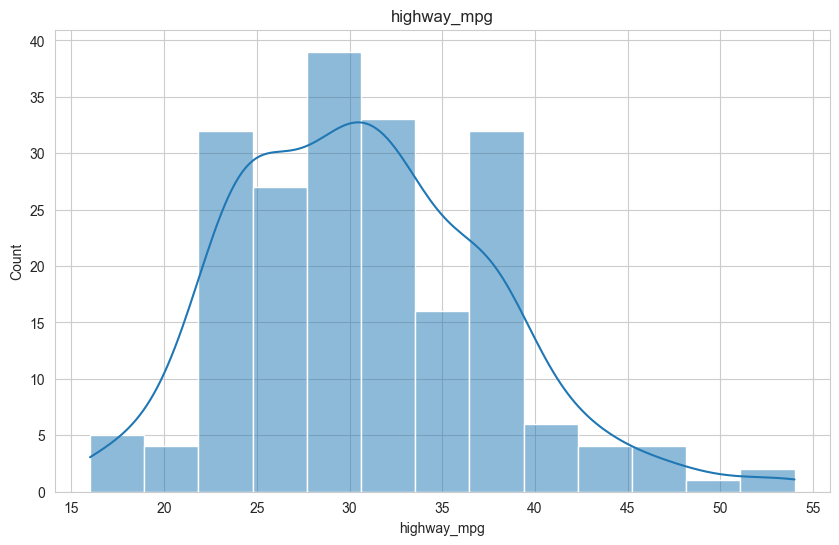

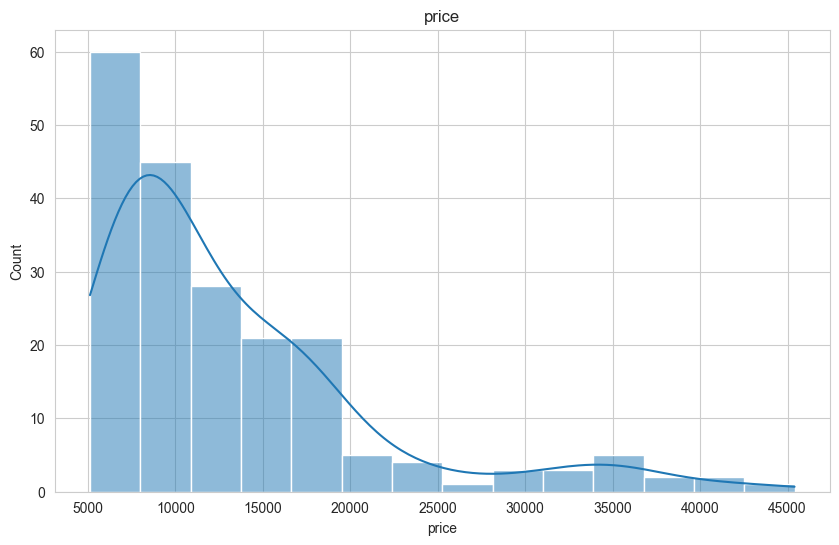

In [23]:
#Distribution plots

for col in num_features:
    sns.histplot(df[col], kde = True)
    plt.title(col)
    plt.show()

In [26]:
#Categorical features 

cat_features = df.select_dtypes(include='object').columns

for col in cat_features:
    print(df[col].value_counts())

make
toyota           32
nissan           18
mazda            17
honda            13
mitsubishi       13
subaru           12
volkswagen       12
peugot           11
volvo            11
dodge             9
bmw               8
mercedes-benz     8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64
fuel_type
gas       185
diesel     20
Name: count, dtype: int64
aspiration
std      168
turbo     37
Name: count, dtype: int64
num_doors
four    114
two      89
Name: count, dtype: int64
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
drive_wheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
engine_location
front    202
rear       3
Name: count, dtype: int64
engine_type
ohc      148
ohcf      15
ohcv      13
dohc      12
l         1

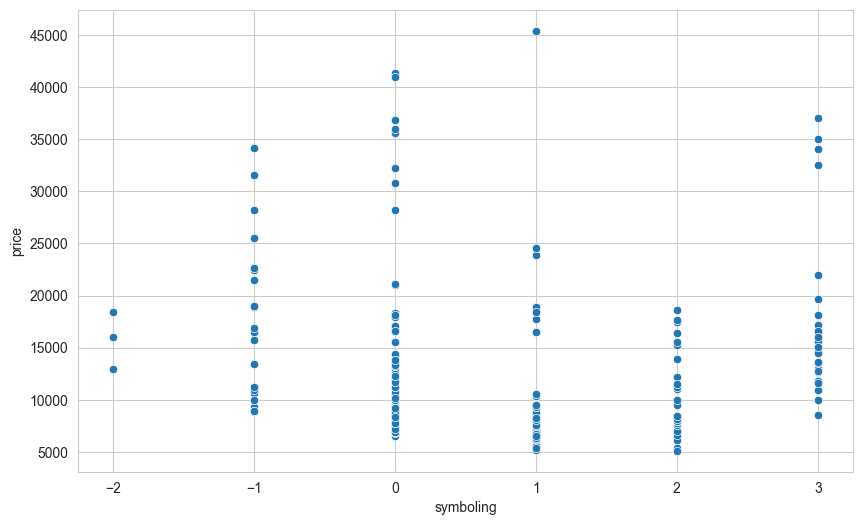

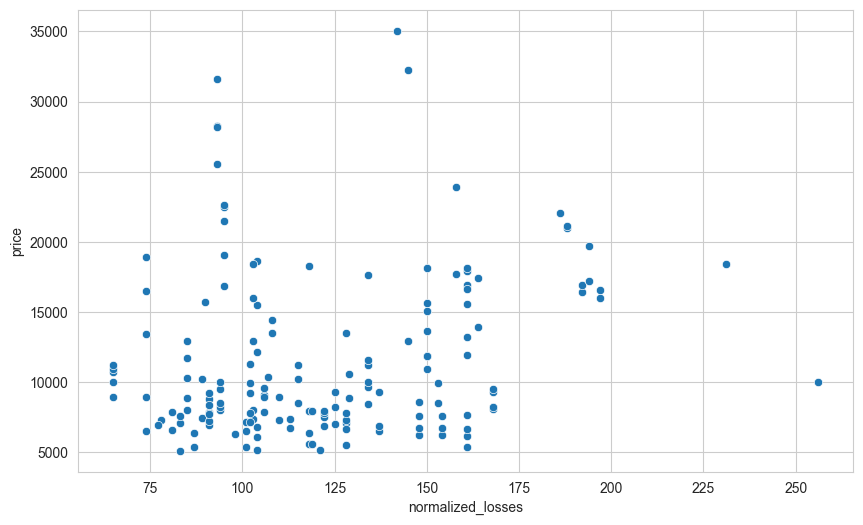

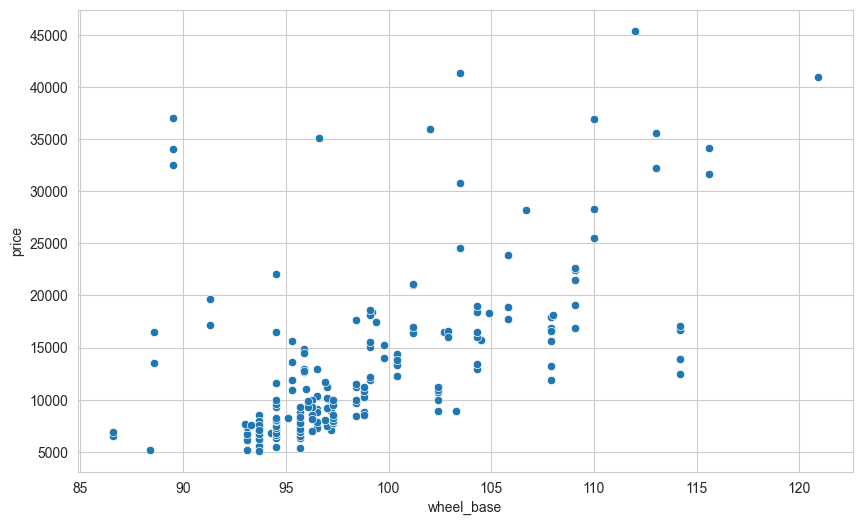

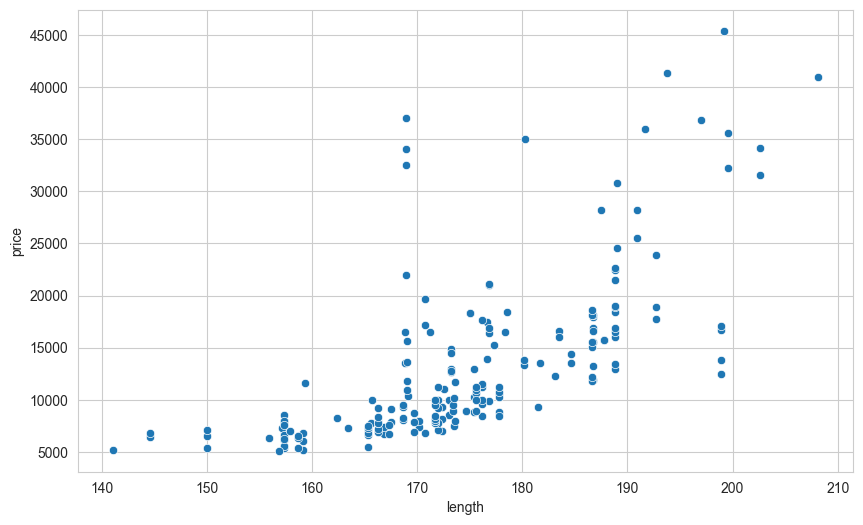

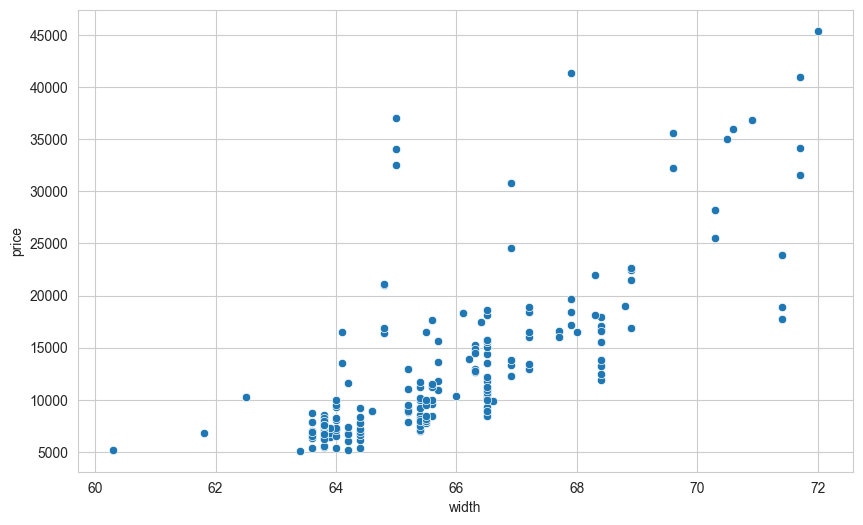

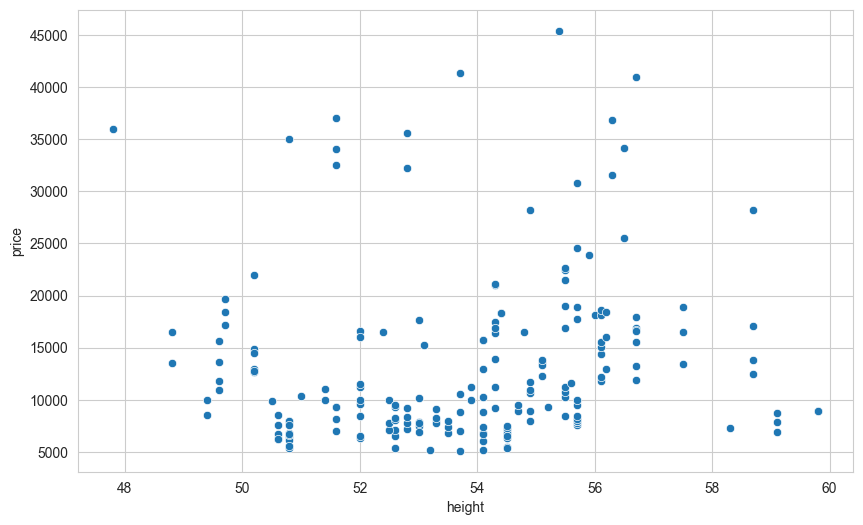

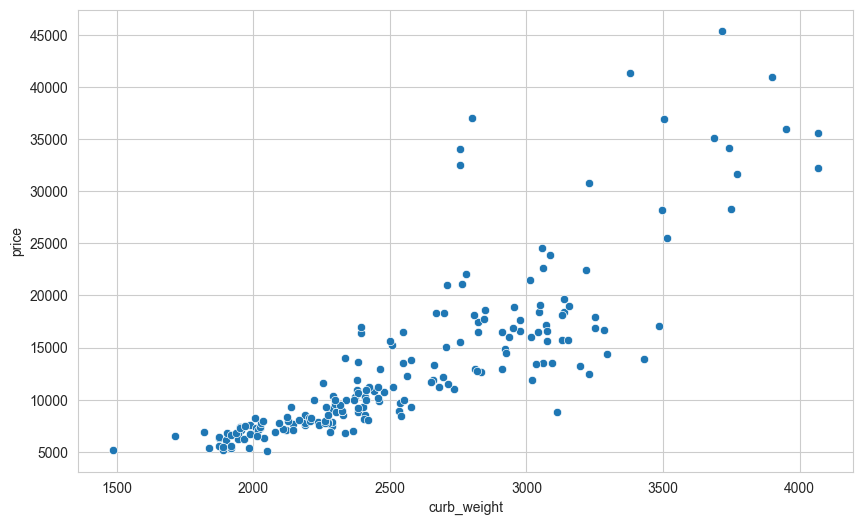

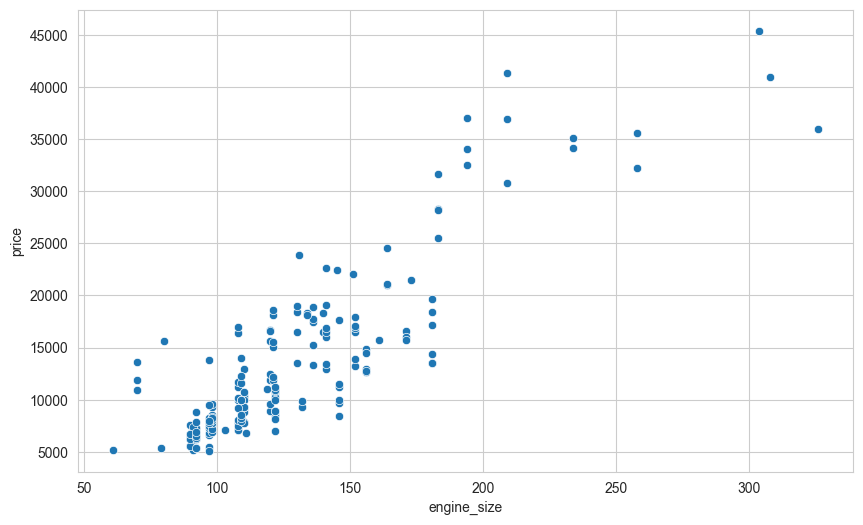

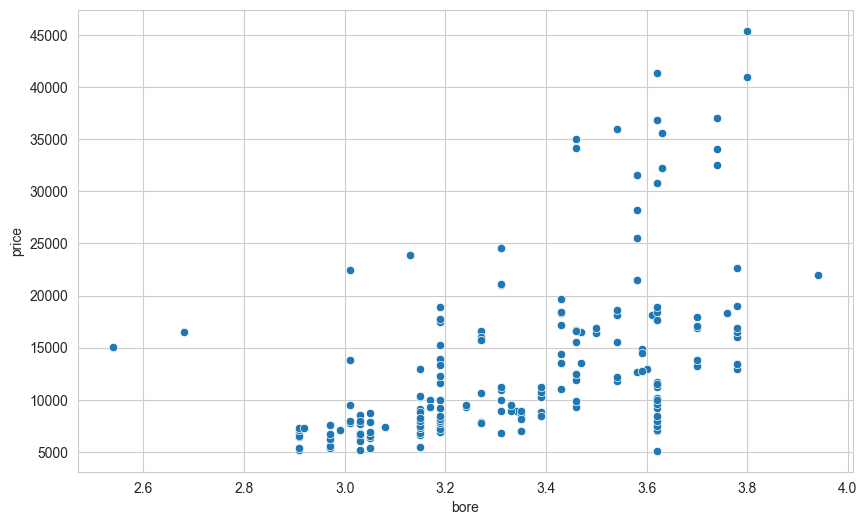

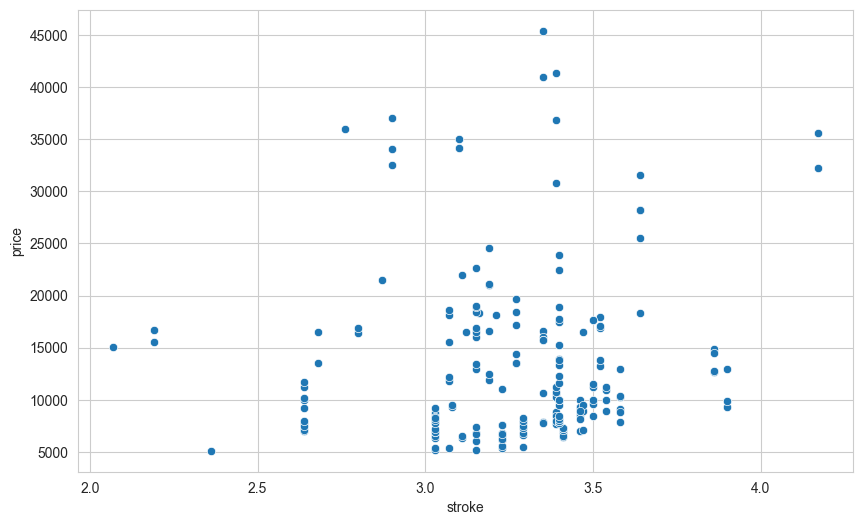

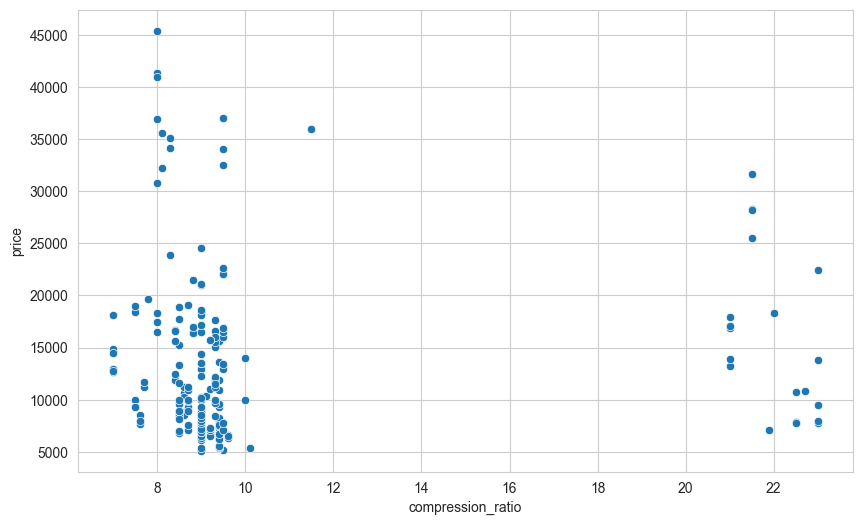

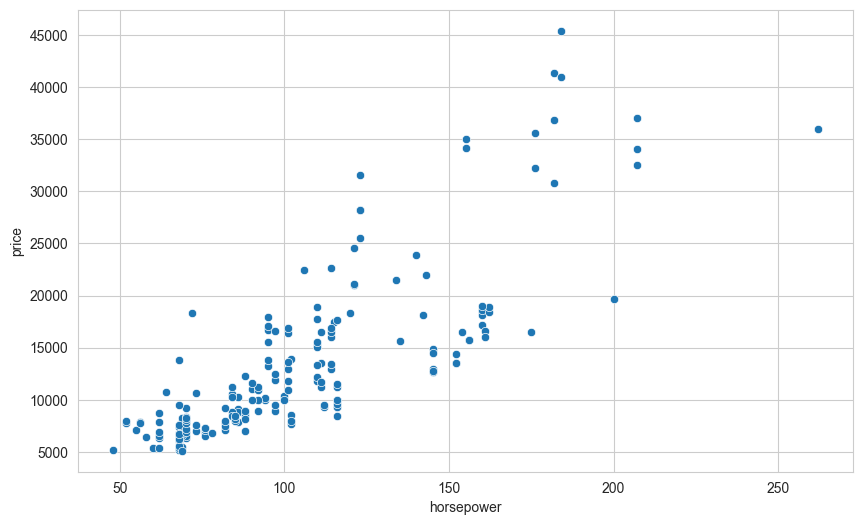

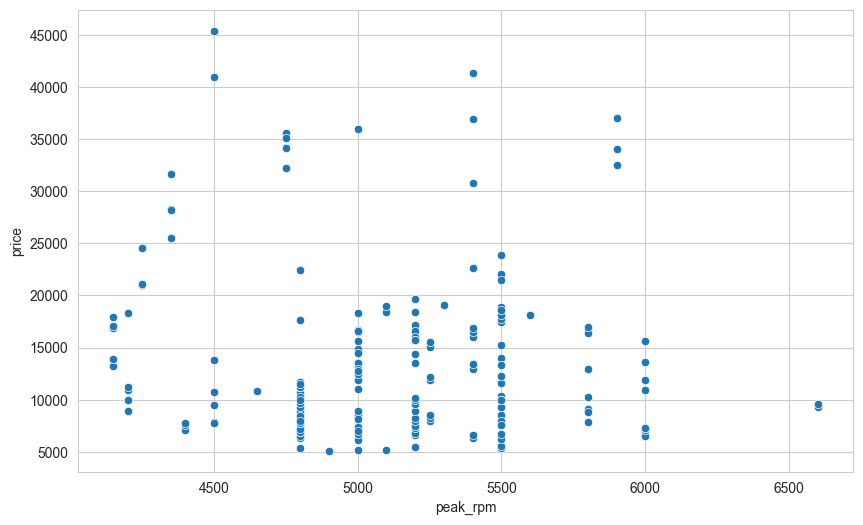

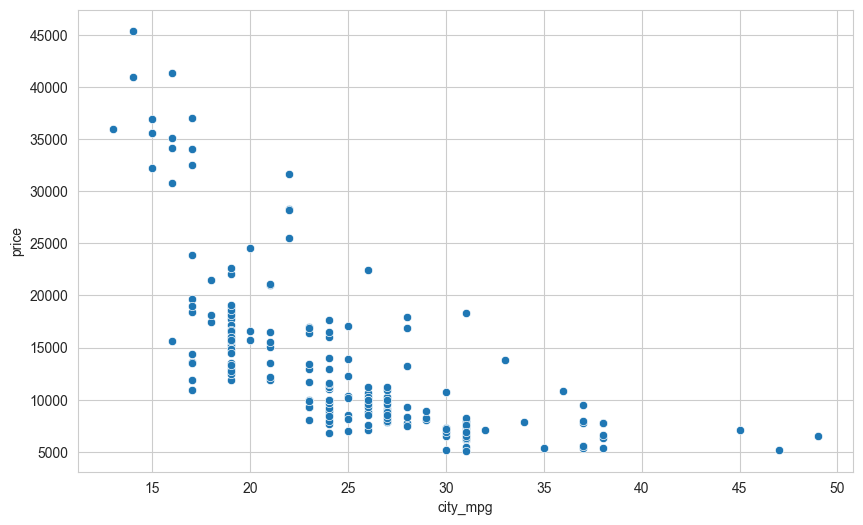

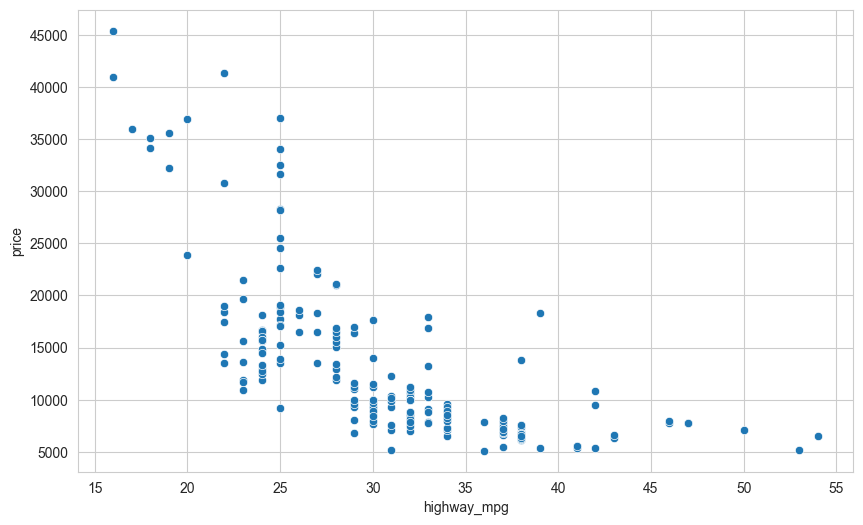

In [27]:
#Bivarate Analysis 

#Target vs numerical 

for col in num_features:
    if col != 'price':
        sns.scatterplot(x=col, y='price', data = df)
        plt.show()

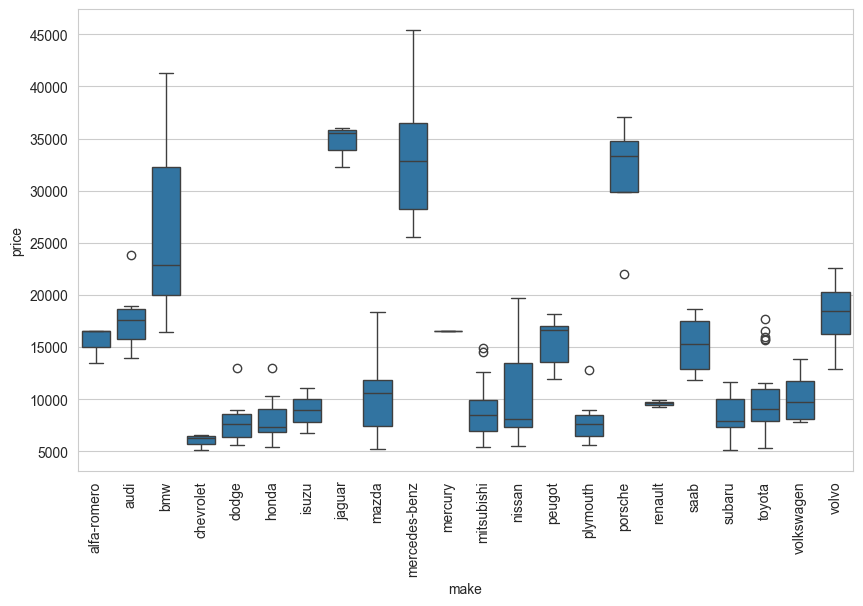

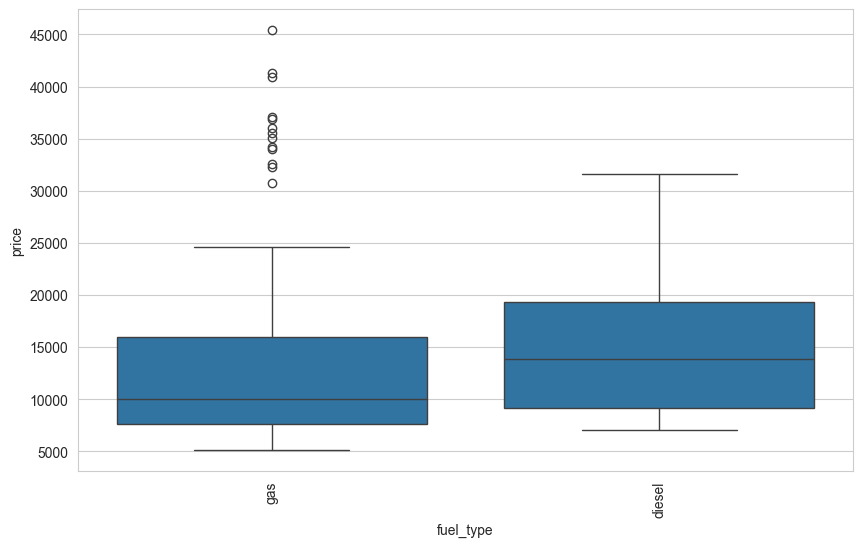

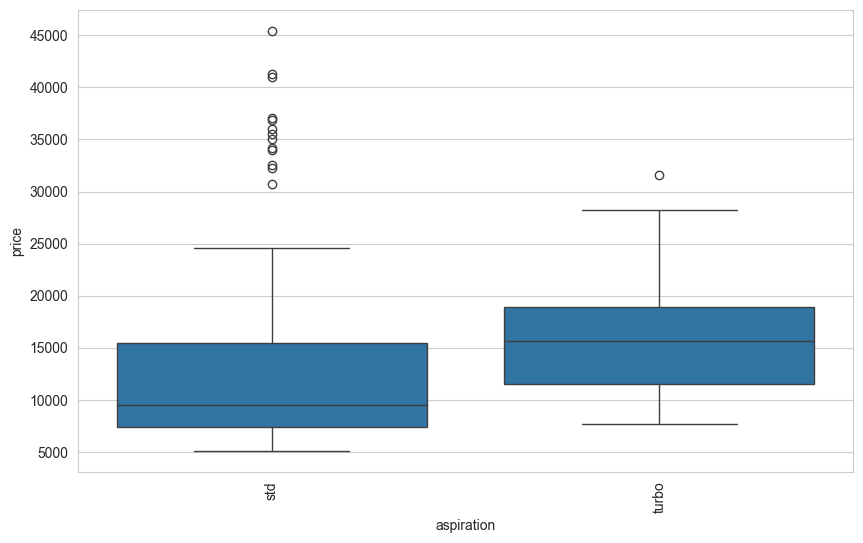

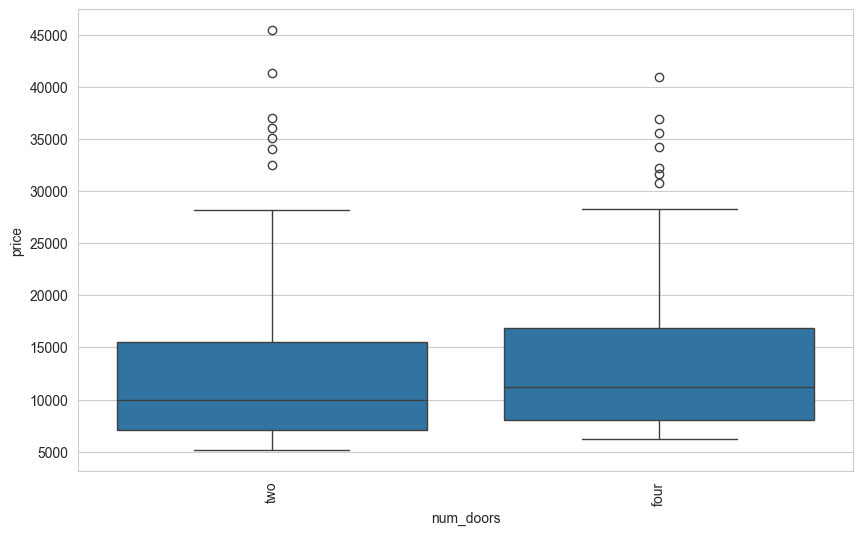

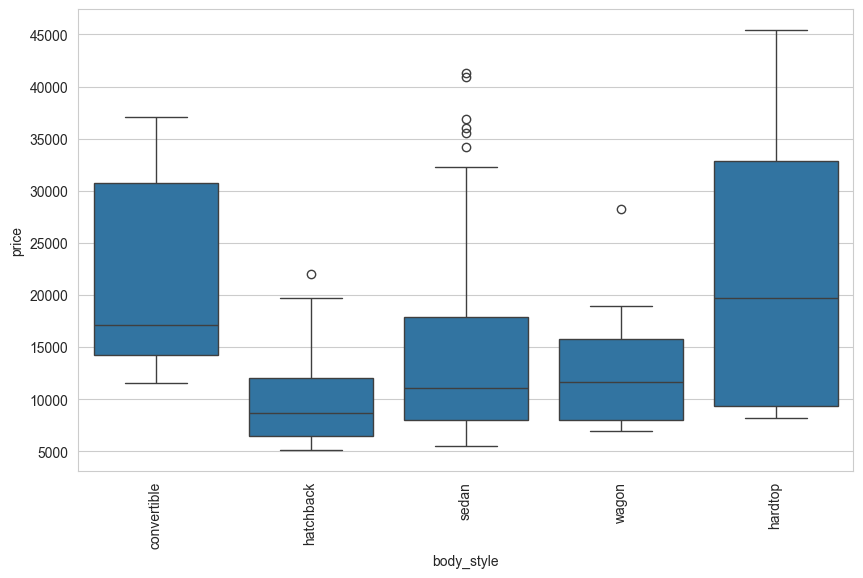

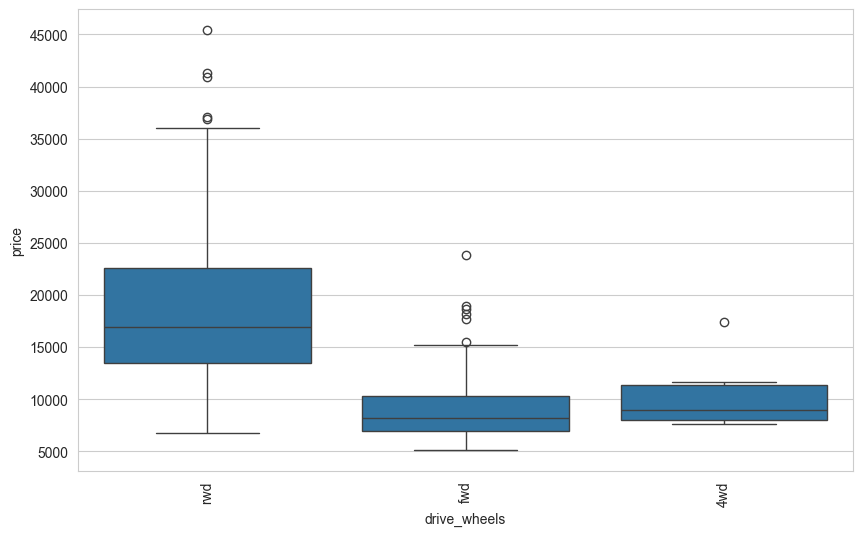

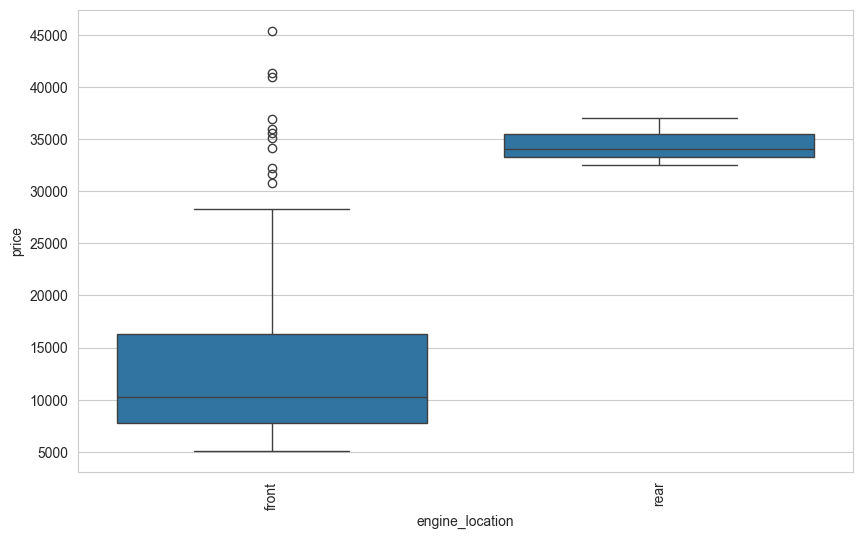

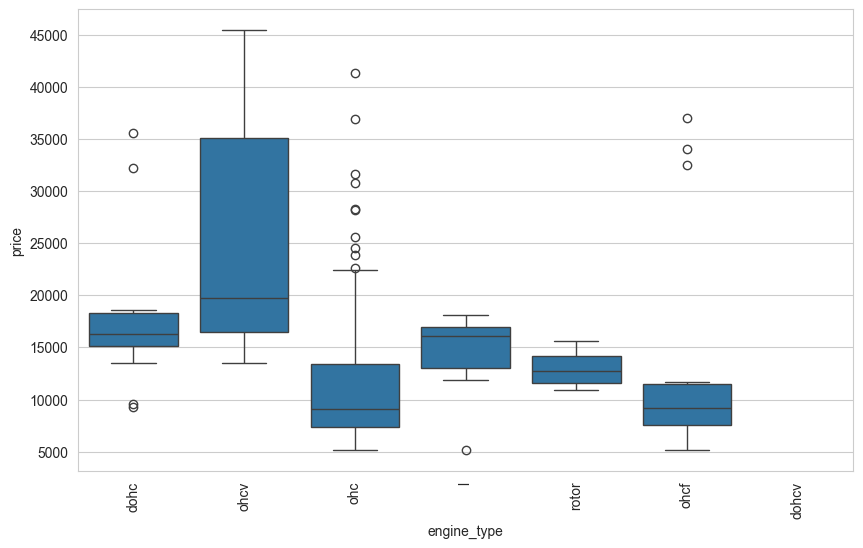

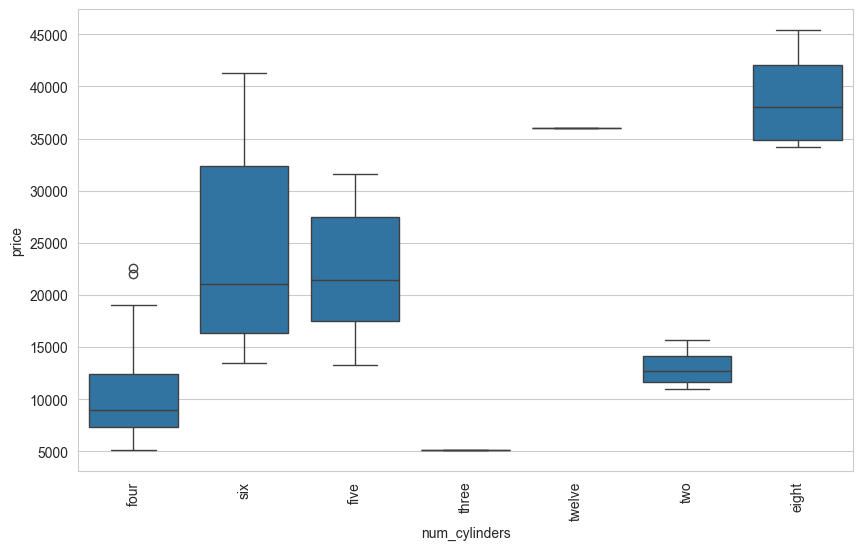

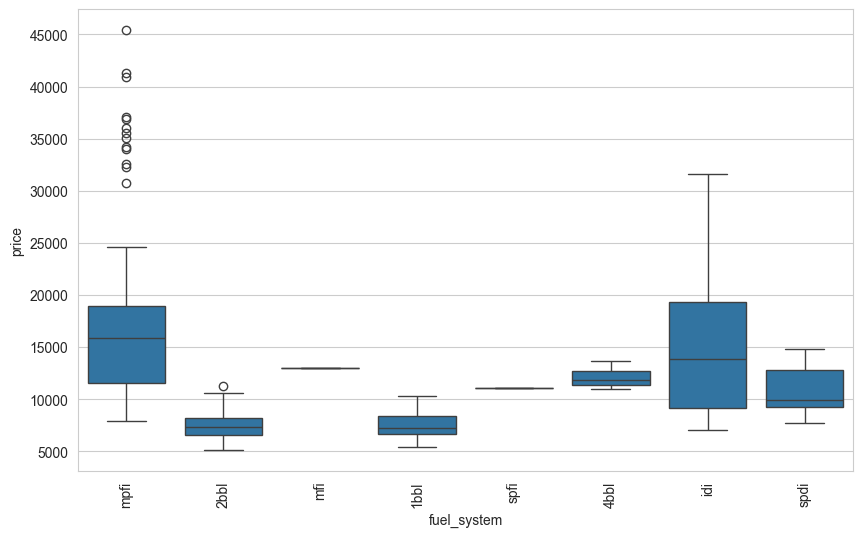

In [28]:
# Target vs categorical 

for col in cat_features:
    sns.boxplot(x =col, y = 'price', data = df)
    plt.xticks(rotation = 90)
    plt.show()